The purpose of this notebook is to process the Ba-133 calibration data in preparation for other analyses (i.e. global fitting). 

The data are baseline-subtracted and filtered to include single events only. 

Last updated 2025-11-02 by Niharika Godbole. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import astropy.units as u
from astropy.time import Time
from astropy.visualization import quantity_support

from specutils import Spectrum1D

from datetime import timedelta
from astropy.table import vstack
import copy
from  astropy.table import Table

import padre_meddea
from padre_meddea.io.file_tools import read_file
import padre_meddea.spectrum.calibration as cal
from padre_meddea.housekeeping import calibration
from padre_meddea.util.pixels import PixelList
import padre_meddea.util.pixels as pixels

quantity_support()
import specutils
specutils.conf.do_continuum_function_check = False
%load_ext autoreload
%autoreload 2

In [2]:
# define global variables.
asics_list=np.arange(4)
pixels_list=np.arange(12)

In [3]:
def agg_spectrum(event_list, asic=None):
    if asic == None: 
        energies = event_list['energy'].value
        event_list = event_list

    else: 
        slice = event_list['asic']==asic
        sliced_event_list = event_list[slice]
        energies = sliced_event_list['energy'].value

    energy_min = np.min(energies)
    energy_max = np.max(energies)
    n_bins = 1500

    energy_edges = np.linspace(energy_min, energy_max, n_bins + 1)

    flux, _ = np.histogram(energies, bins=energy_edges)

    energy_centers = (energy_edges[:-1] + energy_edges[1:]) / 2

    spectrum = Spectrum1D(
        flux=flux * u.count,
        spectral_axis=energy_centers * u.keV,
        )

    return spectrum

def plot_agg(ph_list, pixel_list): 
    "Plot aggregate spectrum for all pixels for all detectors."
    flux=0
    for this_pixel in pixel_list: 
        this_spec=ph_list.spectrum(pixel_list=this_pixel)
        flux+=this_spec.flux.value
    plt.plot(this_spec.spectral_axis, flux)
    plt.title("Aggregate Spectrum (All pixels)")

def plot_all(ph_list, pixel_list):
    "Plot spectra for each pixel for all detectors."
    for this_pixel in all_pixel_list:
        this_spec = ph_list.spectrum(pixel_list=this_pixel)
    plt.plot(this_spec.spectral_axis, this_spec.flux, label=f'Pixel {this_pixel}')
    plt.title("All pixels")

def plot_agg_subplots(ph_list, asic_list, pixel_list):
    "Plot aggregated spectra for each asic in a separate subplot for all pixels."
    fig, ax = plt.subplots(2, 2, figsize=(7,5))
    for this_asic in asics_list:
        plt.subplot(2, 2, this_asic+1)
        this_flux=0
        for this_pixel in pixels_list:
            select_pixel=PixelList(asics=[this_asic], pixels=[this_pixel])
            this_spectrum=ph_list.spectrum(pixel_list=select_pixel)
            this_flux+=this_spectrum.flux # build up the aggregated spectrum by taking the cumulative sum of each individual spectrum.
        plt.plot(this_spectrum.spectral_axis, this_flux, linewidth=0.8) # this is a cheat; assumes that the spectral axes for each pixel are the same.
        plt.title(f'ASIC {this_asic}', fontsize=12)
        plt.xlabel('ADC Channel', fontsize=10)
        plt.ylabel('Counts', fontsize=10)
        plt.xticks(fontsize=9)
        plt.yticks(fontsize=9)
    fig.tight_layout()
    plt.show()

def plot_all_subplots(ph_list, asic_list, pixel_list): 
    "Plot spectra from each pixel in a separate subplot for each detector."
    fig, ax = plt.subplots(2, 2, figsize=(7,5))
    for this_asic in asics_list:
        plt.subplot(2, 2, this_asic+1)
        for this_pixel in pixels_list:
            select_pixel=PixelList(asics=[this_asic], pixels=[this_pixel])
            this_spectrum=ph_list.spectrum(pixel_list=select_pixel)
            plt.plot(this_spectrum.spectral_axis, this_spectrum.flux, linewidth=0.2, label=f'Pixel {this_pixel}')
            plt.title(f'ASIC {this_asic}', fontsize=12)
            plt.xlabel('ADC Channel', fontsize=10)
            plt.ylabel('Counts', fontsize=10)
            plt.xticks(fontsize=9)
            plt.yticks(fontsize=9)
            #plt.ylim(0,2500)
            #plt.legend(fontsize=5, loc='upper right')
    fig.tight_layout()
    plt.show()

def plot_all_pix(ph_list, asic_list, pixel_list): 
    "Plot spectra from each pixel in a separate subplot for each detector."
    for this_asic in asics_list:
        fig, ax = plt.subplots(3, 4, figsize=(10,7))
        plt.suptitle(f'ASIC {this_asic}')
        for this_pixel in pixels_list:
            plt.subplot(3, 4, this_pixel+1)
            select_pixel=PixelList(asics=[this_asic], pixels=[this_pixel])
            this_spectrum=ph_list.spectrum(pixel_list=select_pixel)
            plt.plot(this_spectrum.spectral_axis.value, this_spectrum.flux, alpha=0.5)
            plt.title(f'Pixel {this_pixel}')
            plt.xlabel('ADC Channel')
            plt.ylabel('Counts')
        plt.tight_layout()
        plt.suptitle(f'ASIC {this_asic}')
        plt.show()

In [4]:
data_dir = Path(r"C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis/data")

In [5]:
# load the data recorded during the sealed source testing.
ba_ph_file=Path(data_dir / 'padre_meddea_l0test_photon_20250130T104655_v0.1.0.fits')
ba_hk_file=Path(data_dir / 'padre_meddea_l0test_housekeeping_20250130T104656_v0.1.0.fits')
ba_spec_file=Path(data_dir / 'padre_meddea_l0test_spectrum_20250130T104648_v0.1.0.fits')

In [6]:
ba_hk_ts, ba_cmd_ts = read_file(ba_hk_file)

In [7]:
def plot_hk_converted(hk_ts, key, axlabel, title, plot=False, hist=False):  
    data=hk_ts[key]
    f=calibration.get_calibration_func(key)
    converted_data=f(data)
    print(np.shape(converted_data))

    if plot==True: 
        plt.plot(hk_ts.time.to_datetime(), converted_data, label=key)
        plt.xticks(rotation=45, ha='right') 
        plt.title(title)
        plt.xlabel('UTC Time (HH:MM:SS)')
        plt.ylabel(axlabel)
        plt.grid()
        plt.legend()
        plt.show()

    if hist==True: 
        n, bins, patches=plt.hist(converted_data, bins=30, edgecolor='black', alpha=1, label=key)
        #plt.text(f'Mean: {np.mean(converted_data):.3} \n Standard Dev: {np.std(converted_data):.3}')
        plt.title(key)
        #plt.xlabel(axlabel)
        plt.ylabel('Counts')
        plt.grid()
        plt.legend()
        plt.show()

def filter_and_combine_photon_list(photon_list, time_ranges):
    """
    Filter a PhotonList object based on time ranges and combine the results
    
    Parameters:
    -----------
    photon_list : PhotonList object
        The photon list to filter
    time_ranges : list of tuples
        List of (start_time, end_time) tuples defining time ranges to keep
        
    Returns:
    --------
    combined_photon_list : PhotonList object
        A new PhotonList with data from only the specified time ranges
    """
    # Access the event_list and pkt_list as attributes
    event_list = photon_list.event_list
    pkt_list = photon_list.pkt_list
    
    print(f"Successfully accessed event_list with {len(event_list)} events")
    print(f"Successfully accessed pkt_list with {len(pkt_list)} packets")
    
    # Filter the event_list for each time range and collect results
    filtered_events = []
    for start_time, end_time in time_ranges:
        print(f"Filtering events for time range: {start_time} to {end_time}")
        
        # Create time mask for this range
        event_mask = ((event_list.time >= start_time) & (event_list.time <= end_time))
        
        # Filter the events
        filtered_subset = event_list[event_mask]
        if len(filtered_subset) > 0:
            filtered_events.append(filtered_subset)
            print(f"  Added {len(filtered_subset)} events")
        else:
            print("  No events found in this time range")
    
    # Combine all filtered events
    if filtered_events:
        combined_events = vstack(filtered_events)
        print(f"Combined events: {len(combined_events)} total events")
    else:
        print("No events found in any of the specified time ranges")
        return None
    
    # Filter the pkt_list for each time range and collect results
    filtered_pkts = []
    for start_time, end_time in time_ranges:
        print(f"Filtering packets for time range: {start_time} to {end_time}")
        
        # Create time mask for this range
        pkt_mask = ((pkt_list.time >= start_time) & (pkt_list.time <= end_time))
        
        # Filter the packets
        filtered_subset = pkt_list[pkt_mask]
        if len(filtered_subset) > 0:
            filtered_pkts.append(filtered_subset)
            print(f"  Added {len(filtered_subset)} packets")
        else:
            print("  No packets found in this time range")
    
    # Combine all filtered packets
    if filtered_pkts:
        combined_pkts = vstack(filtered_pkts)
        print(f"Combined packets: {len(combined_pkts)} total packets")
    else:
        print("No packets found in any of the specified time ranges")
        return None
    
    # Create a new PhotonList with the filtered data
    # Since PhotonList might have a specific constructor,
    # let's try to create it the same way as the original
    from padre_meddea.spectrum.spectrum import PhotonList
    
    # Method 1: Try using the class constructor directly
    try:
        filtered_photon_list = PhotonList(event_list=combined_events, pkt_list=combined_pkts)
        print("Created new PhotonList using constructor")
    except Exception as e1:
        print(f"Could not create PhotonList using constructor: {e1}")
        
        # Method 2: Try creating a new instance and then setting attributes
        try:
            filtered_photon_list = PhotonList()
            filtered_photon_list.event_list = combined_events
            filtered_photon_list.pkt_list = combined_pkts
            print("Created new PhotonList and set attributes")
        except Exception as e2:
            print(f"Could not create empty PhotonList and set attributes: {e2}")
            
            # Method 3: As a last resort, modify the original
            try:
                filtered_photon_list = copy.deepcopy(photon_list)
                filtered_photon_list.event_list = combined_events
                filtered_photon_list.pkt_list = combined_pkts
                print("Modified copy of original PhotonList")
            except Exception as e3:
                print(f"All PhotonList creation methods failed: {e3}")
                return None
    
    return filtered_photon_list

def simple_filter_photon_list(photon_list, time_ranges):
    """
    A simpler approach that just filters the event_list and pkt_list in place
    """
    # Access the event_list and pkt_list
    event_list = photon_list.event_list
    pkt_list = photon_list.pkt_list
    
    # Create combined masks for all time ranges
    event_mask = None
    pkt_mask = None
    
    for start_time, end_time in time_ranges:
        # Create mask for this time range
        this_event_mask = ((event_list.time >= start_time) & (event_list.time <= end_time))
        this_pkt_mask = ((pkt_list.time >= start_time) & (pkt_list.time <= end_time))
        
        # Combine with previous masks using OR
        if event_mask is None:
            event_mask = this_event_mask
            pkt_mask = this_pkt_mask
        else:
            event_mask = event_mask | this_event_mask
            pkt_mask = pkt_mask | this_pkt_mask
    
    # Apply the masks
    filtered_events = event_list[event_mask]
    filtered_pkts = pkt_list[pkt_mask]
    
    print(f"Filtered {len(filtered_events)} events out of {len(event_list)}")
    print(f"Filtered {len(filtered_pkts)} packets out of {len(pkt_list)}")
    
    # Create a copy of the original
    filtered_photon_list = copy.deepcopy(photon_list)
    
    # Set the filtered data
    filtered_photon_list.event_list = filtered_events
    filtered_photon_list.pkt_list = filtered_pkts
    
    return filtered_photon_list

def calibrate_raw_spec(ph_list): 
    all_pixel_list = PixelList().all()

    lin_cal_params = cal.calibrate_phlist_barium_linear(ph_list)
    cal_ph_list = cal.calibrate_linear_phlist(ph_list, lin_cal_params)

    return cal_ph_list

def single_events(event_list): 
    unique, unique_indices, multiplicity = np.unique(event_list['time'], return_index=True, return_counts=True)
    masked_indices = unique_indices[np.where(multiplicity == 1)]
    single_events = event_list[masked_indices]
    print(f"percentage of single-trigger events:", (len(unique_indices[np.where(multiplicity == 1)])/len(single_events['time']))*100, '%')

    return single_events #event_list containing only single events

Confirm that the HV setpoint was -300V during this test. The higher the reverse bias, the less tailing is expected by reducing the amount of charge trapping / incomplete charge collection that contributes to tailing. The amount of tailing observed in the 81 keV double line in the Am241 calibration data appears to be less than that of the 81 keV double line in the Ba133 data. If the reverse bias was indeed -300V in each case, then we are not sure how to explain the discrepancy. 

(877,)


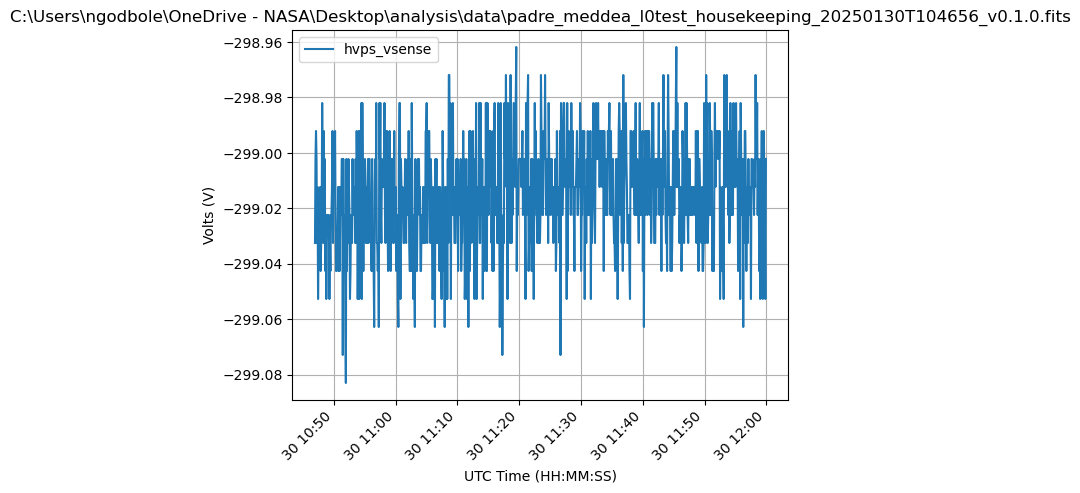

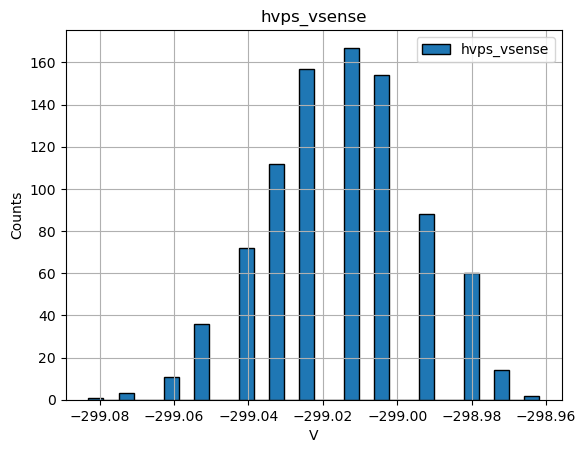

In [8]:
# Confirm that HV = -300V.
plot_hk_converted(ba_hk_ts, 'hvps_vsense', 'Volts (V)', str(ba_hk_file), plot=True, hist=True)

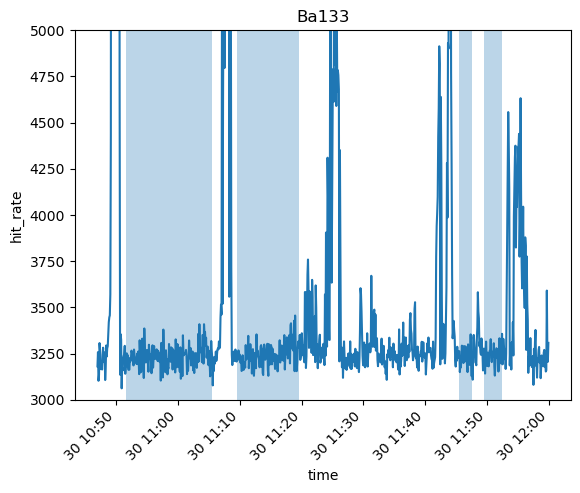

In [9]:
# Plot the hit_rate to see which intervals are not dominated by microphonics. 
plt.plot(ba_hk_ts.time.to_datetime(), ba_hk_ts['hit_rate'])
plt.xticks(rotation=45, ha='right') 
plt.title('Ba133')
plt.ylabel('hit_rate')
plt.xlabel('time')

'''
# select an interval not dominated by microphonics. 
ba_good_tr = [(Time('2025-01-30T10:51'), Time('2025-01-30T11:06')), 
              (Time('2025-01-30T11:09'), Time('2025-01-30T11:20')),
              (Time('2025-01-30T11:27'), Time('2025-01-30T11:41')),
              (Time('2025-01-30T11:45'), Time('2025-01-30T11:48')),
              (Time('2025-01-30T11:49'), Time('2025-01-30T11:53'))]
'''
# Still results in significant tailing on the 81 keV line.

# Try clipping the microphonics out more aggressivley: 
ba_good_tr = [(Time('2025-01-30T10:51:30'), Time('2025-01-30T11:05:30')), 
              (Time('2025-01-30T11:09:30'), Time('2025-01-30T11:19:30')),
              #(Time('2025-01-30T11:27'), Time('2025-01-30T11:41')),
              (Time('2025-01-30T11:45:30'), Time('2025-01-30T11:47:30')),
              (Time('2025-01-30T11:49:30'), Time('2025-01-30T11:52:30'))]
for this_tr in ba_good_tr: 
    plt.axvspan(this_tr[0].to_datetime(), this_tr[1].to_datetime(), alpha=0.3)
plt.ylim(3000,5000)
plt.show()

In [10]:
ba_duration = timedelta(0)
for this_time in ba_good_tr: 
    print(this_time[1].to_datetime() - this_time[0].to_datetime())
    ba_duration += (this_time[1].to_datetime() - this_time[0].to_datetime())

0:14:00
0:10:00
0:02:00
0:03:00


In [13]:
print('Total duration of "clean" measurement: ', ba_duration.total_seconds()*u.s.to(u.min)*u.min)

Total duration of "clean" measurement:  29.0 min


In [14]:
ba_ph_list = read_file(data_dir / ba_ph_file)

In [15]:
# Stack the photon lists that correspond to the clipped times. 
filtered_ba_ph_list = simple_filter_photon_list(ba_ph_list, ba_good_tr)
    
# Print information about the filtered photon list 
print("\nFiltered PhotonList:")
print(f"Event count: {len(filtered_ba_ph_list.event_list)}")
print(f"Packet count: {len(filtered_ba_ph_list.pkt_list)}")
print(f"Time range: {filtered_ba_ph_list.event_list.time.min().to_datetime()} - {filtered_ba_ph_list.event_list.time.max().to_datetime()}")

Filtered 2778988 events out of 7048844
Filtered 19421 packets out of 49217

Filtered PhotonList:
Event count: 2778988
Packet count: 19421
Time range: 2025-01-30 10:51:30.000470 - 2025-01-30 11:52:29.998231


In [16]:
# Create a copy of the original ph_list for later comparison to the baseline subtracted spectrum. 
non_bl_sub_ba_list = copy.deepcopy(filtered_ba_ph_list)

In [17]:
# Remove the BL. 
# Since the calibration from padre_meddea works on the 'atod' column, subtract the baseline from this column and then apply the calibration. 
filtered_ba_ph_list.event_list['atod'] = (np.array(filtered_ba_ph_list.event_list['atod'], dtype='float64') - np.array(filtered_ba_ph_list.event_list['baseline'], dtype='float64')) + np.mean(np.array(filtered_ba_ph_list.event_list['baseline'], dtype='float64'))

Now, apply the energy calibration from padre_meddea. 

In [18]:
all_pixel_list = PixelList().all()

In [19]:
ba_lin_cal_params = cal.calibrate_phlist_barium_linear(filtered_ba_ph_list)

In [20]:
# Calibrated Ba-133 ph_list, not baseline-subtracted. 
non_bl_sub_cal_ba_ph_list = cal.calibrate_linear_phlist(non_bl_sub_ba_list, ba_lin_cal_params)
# Calibrated Ba-133 ph_list baseline-subtracted. 
cal_ba_ph_list = cal.calibrate_linear_phlist(filtered_ba_ph_list, ba_lin_cal_params)

Compare the baseline-subtracted spectrum to the non baseline-subtracted spectrum. 

C:\Users\ngodbole\AppData\Local\Temp\1\ipykernel_27672\3589721446.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=12)


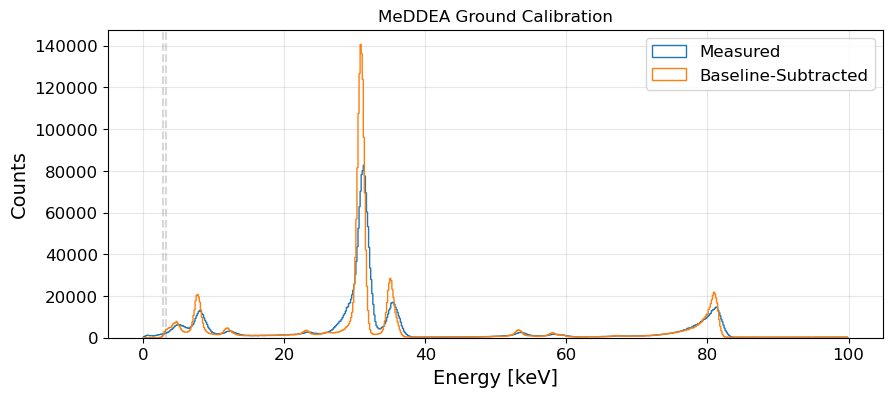

In [22]:
# Create the plots
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))

ax1.set_xlabel("Energy [keV]", fontsize=14)
ax1.set_ylabel("Counts", fontsize=14)
#ax1.set_ylim(bottom=0)
#ax1.set_xlim(0, 90)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title("MeDDEA Ground Calibration / Ba-133 / Sum of all 48 pixels", 
             fontsize=16, fontweight='bold')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

plt.hist(non_bl_sub_cal_ba_ph_list.event_list['energy'], histtype = 'step', bins=np.arange(0,100,0.15), label='Measured')
plt.hist(cal_ba_ph_list.event_list['energy'], histtype = 'step', bins=np.arange(0,100,0.15), label='Baseline-Subtracted')
plt.axvline(2.8, color='gray', linestyle='dashed', alpha=0.3) # SPix threshold
plt.axvline(3.2, color='gray', linestyle='dashed', alpha=0.3) # LPix threshold
#plt.yscale('log')
plt.title('MeDDEA Ground Calibration')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts')
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

Subtracting the baseline noticeably improves the energy resolution. There is no reason why we should not do this when evaluating the spectral resolution of the instrument. The edge at low energies is likely due to the low energy thresholds on the small pixels (2.8 keV) and on the large pixels (3.2 keV). 

In [23]:
# Olivier: Remove counts > 1 keV and < 110 keV
cal_ba_ph_list.event_list = cal_ba_ph_list.event_list[(cal_ba_ph_list.event_list['energy'] >= 1) & (cal_ba_ph_list.event_list['energy'] <= 110)]

In [24]:
ba_single_events = single_events(cal_ba_ph_list.event_list)

percentage of single-trigger events: 100.0 %


In [25]:
# Export the event_list for the calibrated data. 
# Convert TimeSeries to Table and write to FITS.
Table(ba_single_events).write('cal_ba133_event_list_1to110keV_single_events_bl_sub.fits', overwrite=True)

print("All event lists exported successfully!")

All event lists exported successfully!


The 81 keV line has a larger tail than expected. Is this a constant feature in the data? Compare data from each time interval.

Successfully accessed event_list with 2513886 events
Filtering events for time range: 2025-01-30T10:51:30.000 to 2025-01-30T11:05:30.000
Successfully accessed event_list with 2513886 events
Filtering events for time range: 2025-01-30T11:09:30.000 to 2025-01-30T11:19:30.000
Successfully accessed event_list with 2513886 events
Filtering events for time range: 2025-01-30T11:45:30.000 to 2025-01-30T11:47:30.000
Successfully accessed event_list with 2513886 events
Filtering events for time range: 2025-01-30T11:49:30.000 to 2025-01-30T11:52:30.000


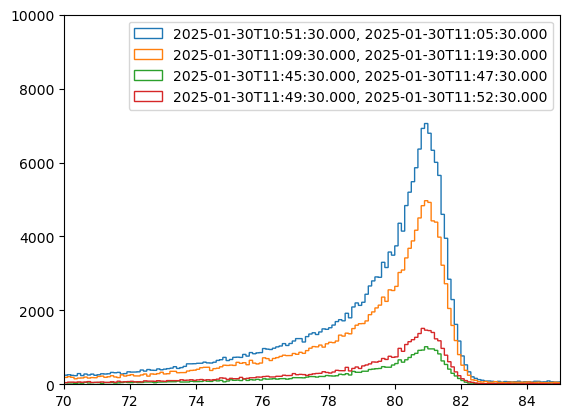

In [ ]:
for start_time, end_time in ba_good_tr: 
    print(f"Successfully accessed event_list with {len(ba_single_events)} events")
    print(f"Filtering events for time range: {start_time} to {end_time}")
    # Create time mask for this range.
    event_mask = ((ba_single_events.time >= start_time) & (ba_single_events.time <= end_time))
    filtered_event_list = ba_single_events[event_mask]
    plt.hist(filtered_event_list['energy'], histtype='step', bins=np.arange(0,100,0.1), label=f'{start_time}, {end_time}')

plt.legend()
plt.xlim(70,85)
plt.ylim(0,10000)
plt.show()

This data has already been calibrated and filtered to include single events only. The amount of tailing is significant for all time intervals. 

Olivier suggested filtering the event lists such that only counts from Pixels 9, 10, and 11 are kept. Since these are small pixels, the energy resolution should be better than their large counterparts. Pixel 8 is excluded from this list, since it borders the Guard Ring, and is therefore the likelihood of it experiencing charge sharing events (which lead to increased tailing and poorer energy resolution) with the Guard Ring is higher. We want to eliminate this possibility, hence we are only looking at events from Pixels 9, 10, and 11. 

In [ ]:
ba133_single_events_spix = ba_single_events[(ba_single_events['pixel'] == 9) | (ba_single_events['pixel'] == 10) | (ba_single_events['pixel'] == 11)]

Percentage of single-trigger events:  96.70302362599699 %


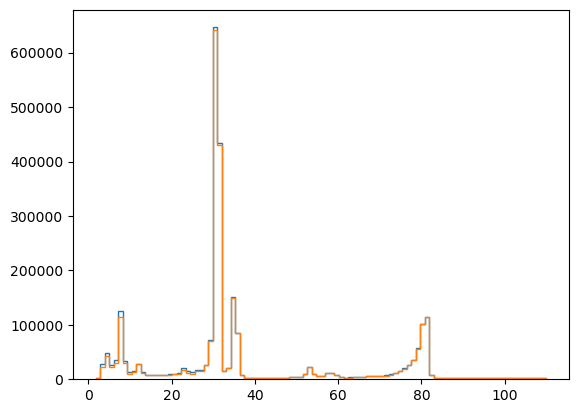

In [26]:
plt.hist(cal_ba_ph_list.event_list['energy'], 
         histtype='step',
         bins=100)

plt.hist(ba_single_events['energy'], 
         histtype='step',
         bins=100)

print('Percentage of single-trigger events: ', len(ba_single_events['energy']) / len(cal_ba_ph_list.event_list['energy'])*100, '%' )
plt.show()

In [27]:
# Count rate for Ba133 measurement? 
print('Total count rate (single-events only): ', np.sum(agg_spectrum(ba_single_events).flux) / (ba_duration.total_seconds()*u.s))

Total count rate (single-events only):  1444.7620689655173 ct / s


In [113]:
np.savez(f'aggregated_ba133_data_1kevto110kev_agg_clip_single_events_bl_sub.npz', 
         energy=agg_spectrum(ba_single_events).spectral_axis.value, 
         flux=agg_spectrum(ba_single_events).flux)

In [ ]:
np.savez(f'aggregated_ba133_data_1kevto110kev_spix_single_events_bl_sub.npz', 
         energy=agg_spectrum(ba133_single_events_spix).spectral_axis.value, 
         flux=agg_spectrum(ba133_single_events_spix).flux)

Sanity check; see how the spectra look for individual ASICs. 

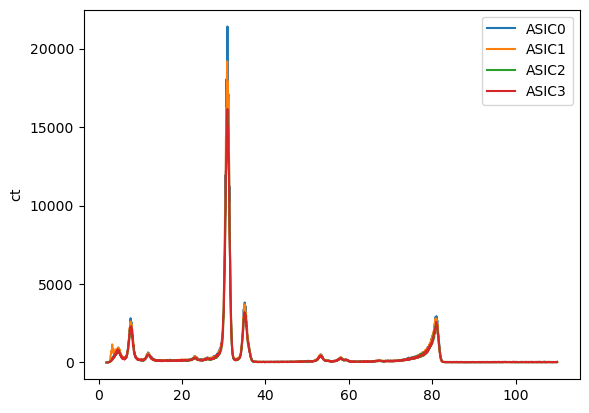

In [115]:
for this_asic in asics_list: 
    spec = agg_spectrum(event_list=ba_single_events, asic=this_asic)

    #np.savez(f'asic{this_asic}_ba133_data.npz', 
    #     energy=spec.spectral_axis.value, 
    #     flux=spec.flux)
    
    plt.plot(spec.spectral_axis.value, spec.flux, label=f'ASIC{this_asic}')
    plt.legend()
plt.show()

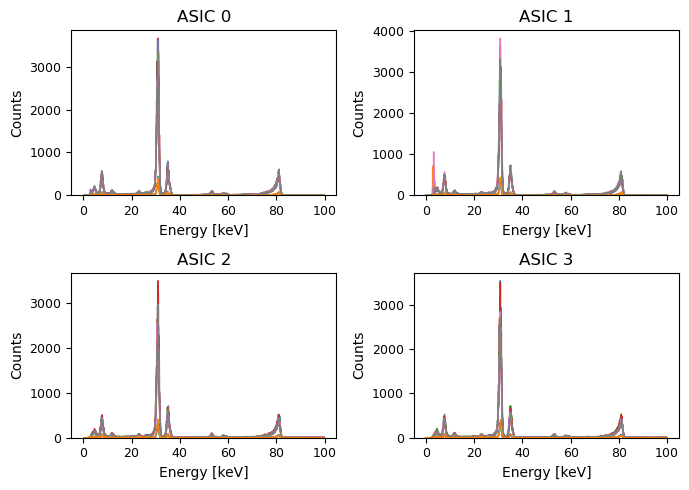

In [147]:
fig, ax = plt.subplots(2, 2, figsize=(7,5))
for this_asic in asics_list:
    plt.subplot(2, 2, this_asic+1)
    # Filter once per ASIC to reduce repeated operations
    asic_data = cal_ba_ph_list.event_list[cal_ba_ph_list.event_list['asic']==this_asic]
    for this_pixel in pixels_list:
        pixel_data = asic_data[asic_data['pixel']==this_pixel]['energy']
        plt.hist(pixel_data, 
                 bins=np.arange(0,100,0.1), 
                 histtype='step',
                 label=f'Pixel {this_pixel}')
    plt.title(f'ASIC {this_asic}', fontsize=12)
    plt.xlabel('Energy [keV]', fontsize=10)
    plt.ylabel('Counts', fontsize=10)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    # plt.legend(fontsize=5, loc='upper right')  # Uncomment if needed
fig.tight_layout()
plt.show()  # Only show once at the end

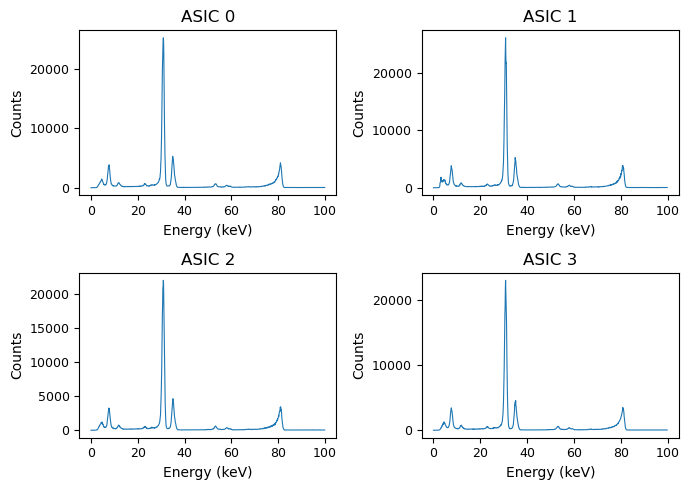

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(7,5))
for this_asic in asics_list:
    plt.subplot(2, 2, this_asic+1)
    this_flux=0
    for this_pixel in pixels_list:
        select_pixel=PixelList(asics=[this_asic], pixels=[this_pixel])
        this_spectrum=cal_ba_ph_list.spectrum(pixel_list=select_pixel, calibrate=True)
        this_flux+=this_spectrum.flux
    #np.savez(f'asic{this_asic}_ba133_data.npz', 
    #     energy=this_spectrum.spectral_axis.value, 
    #     flux=this_flux.value)
    #for this_roi in ba_rois: 
    #    plt.axvspan(this_roi[0], this_roi[1], alpha=0.3)
    plt.plot(this_spectrum.spectral_axis, this_flux, linewidth=0.8)
    plt.title(f'ASIC {this_asic}', fontsize=12)
    plt.xlabel('Energy (keV)', fontsize=10)
    plt.ylabel('Counts', fontsize=10)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
fig.tight_layout()
plt.show()